# 01 — Exploratory Data Analysis

This notebook performs EDA on the **UCI SMS Spam Collection** (English) and
explores class distribution, message length characteristics, and key statistical
insights that inform the feature engineering and modelling pipeline.

> **Pipeline position**: Raw data → EDA → Feature Engineering (02) → Augmentation (03) → Training (04) → Evaluation (05)

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
print('Libraries loaded.')

Libraries loaded.


## 1. Load the UCI SMS Spam Collection

In [2]:
DATA_PATH = '../dataset/Spam SMS Collection'

df = pd.read_csv(DATA_PATH, sep='\t', names=['label', 'text'], encoding='latin-1')
df['label_int'] = (df['label'] == 'spam').astype(int)

print(f'Shape: {df.shape}')
df.head()

Shape: (5572, 3)


,label,text,label_int
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


## 2. Basic Statistics

In [3]:
print('=== Null values ===')
print(df.isnull().sum())

print('\n=== Duplicate rows ===')
print(f"Total duplicates: {df.duplicated(subset='text').sum()}")

print('\n=== Label distribution ===')
print(df['label'].value_counts())
print(f"\nSpam ratio: {df['label_int'].mean():.2%}")

=== Null values ===
label        0
text         0
label_int    0
dtype: int64

=== Duplicate rows ===
Total duplicates: 403

=== Label distribution ===
label
ham     4825
spam     747
Name: count, dtype: int64

Spam ratio: 13.41%


## 3. Class Distribution — Imbalance Visualisation

C:\Users\nj465\AppData\Local\Temp\ipykernel_23048\200321530.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=['#22c55e', '#ef4444'], ax=axes[0])


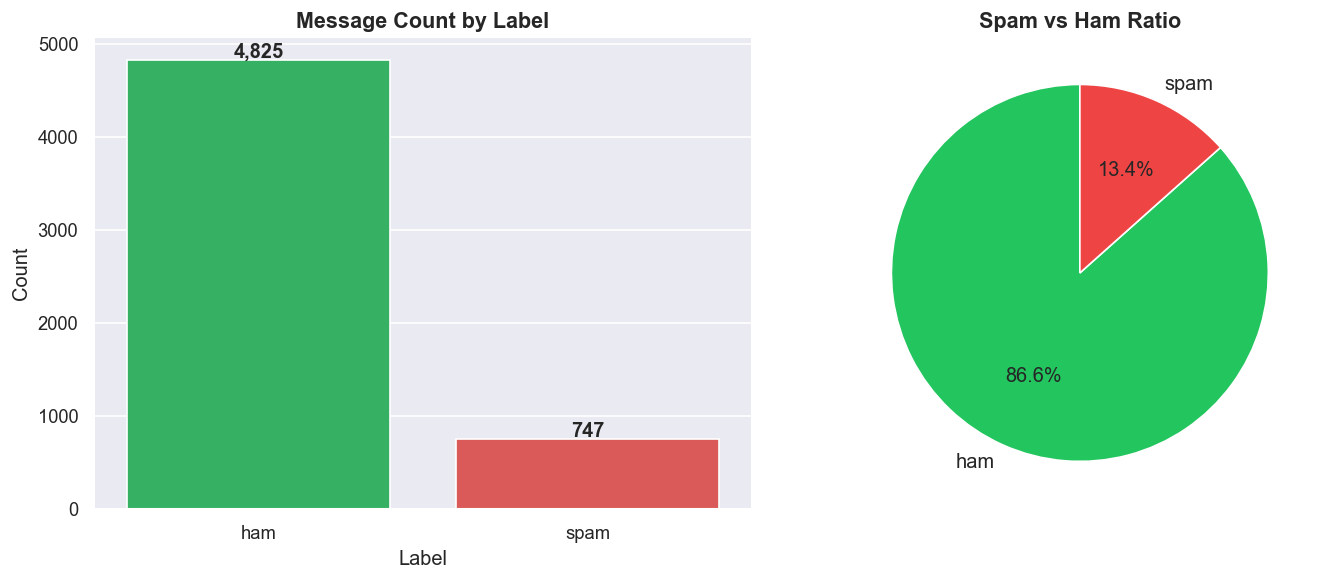

NOTE: Dataset is heavily imbalanced (13.4% spam). We use weighted loss — NOT oversampling — for MuRIL.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['label'].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette=['#22c55e', '#ef4444'], ax=axes[0])
axes[0].set_title('Message Count by Label', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            autopct='%1.1f%%', colors=['#22c55e', '#ef4444'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Spam vs Ham Ratio', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../readme-resources/eda_class_dist.png', bbox_inches='tight')
plt.show()
print('NOTE: Dataset is heavily imbalanced (13.4% spam). We use weighted loss — NOT oversampling — for MuRIL.')

## 4. Message Length Analysis

In [5]:
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print('=== Character count stats by label ===')
print(df.groupby('label')[['char_count', 'word_count']].describe().round(1))

=== Character count stats by label ===
      char_count                                                word_count  \
           count   mean   std   min    25%    50%    75%    max      count   
label                                                                        
ham       4825.0   71.6  58.5   2.0   33.0   52.0   93.0  910.0     4825.0   
spam       747.0  139.1  29.0  13.0  133.0  149.0  158.0  224.0      747.0   

                                                 
       mean   std  min   25%   50%   75%    max  
label                                            
ham    14.3  11.5  1.0   7.0  11.0  19.0  171.0  
spam   23.9   5.8  2.0  22.0  25.0  28.0   35.0  


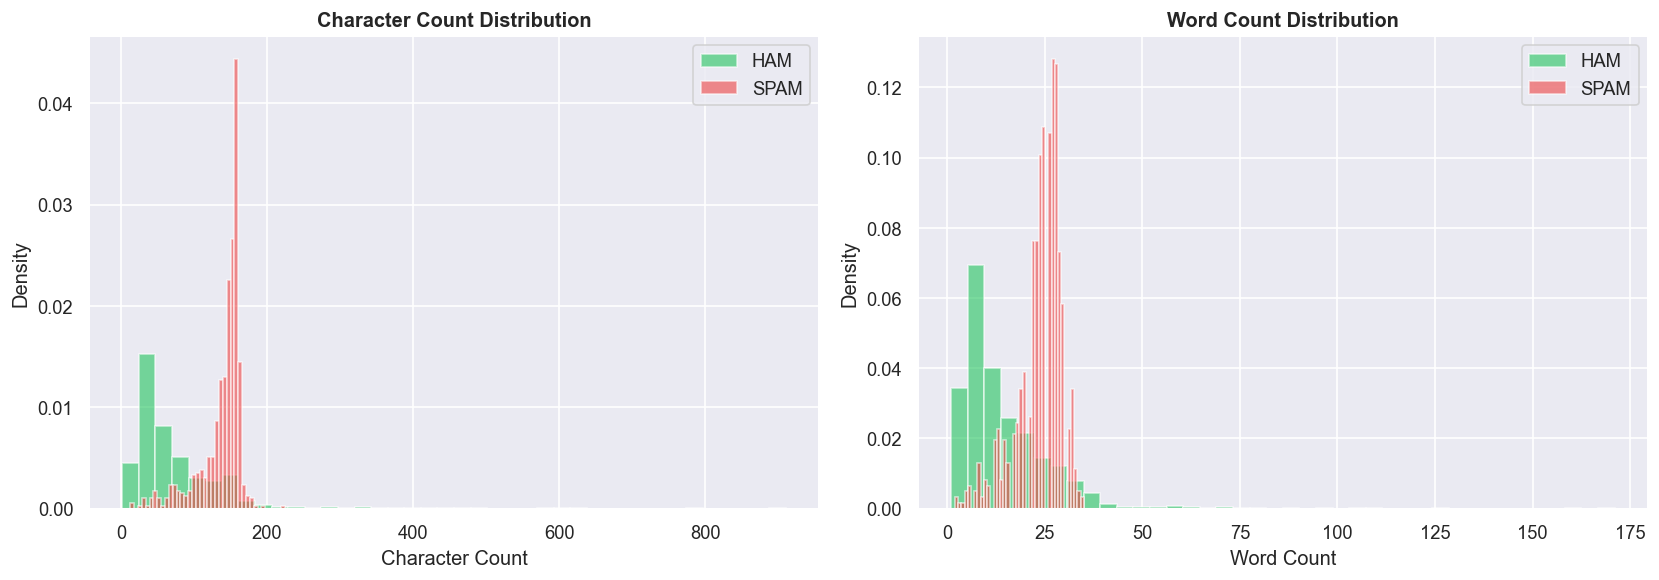

INSIGHT: Spam messages tend to be longer (higher char/word count) than ham messages.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (col, title) in enumerate([('char_count', 'Character Count'), ('word_count', 'Word Count')]):
    for label, color in [('ham', '#22c55e'), ('spam', '#ef4444')]:
        axes[i].hist(df[df['label'] == label][col], bins=40, alpha=0.6,
                     label=label.upper(), color=color, density=True)
    axes[i].set_title(f'{title} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(title); axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../readme-resources/eda_length_dist.png', bbox_inches='tight')
plt.show()
print('INSIGHT: Spam messages tend to be longer (higher char/word count) than ham messages.')

## 5. Spam Signal Features

In [7]:
import re

df['contains_currency']  = df['text'].str.contains(r'[€$¥£₹₺]', regex=True).astype(int)
df['contains_number']    = df['text'].str.contains(r'\d', regex=True).astype(int)
df['contains_url']       = df['text'].str.contains(r'https?://|www\.', regex=True, case=False).astype(int)
df['contains_phone']     = df['text'].str.contains(r'\b\d{10,13}\b', regex=True).astype(int)
df['caps_ratio']         = df['text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len([c for c in x if c.isalpha()]), 1)
)

feature_cols = ['contains_currency', 'contains_number', 'contains_url', 'contains_phone']
spam_rates = df.groupby('label')[feature_cols].mean() * 100
print('=== Feature prevalence by label (%) ===')
print(spam_rates.round(1).T.to_string())

=== Feature prevalence by label (%) ===
label               ham  spam
contains_currency   0.4  34.4
contains_number    15.6  94.8
contains_url        0.0  14.2
contains_phone      0.0  50.6


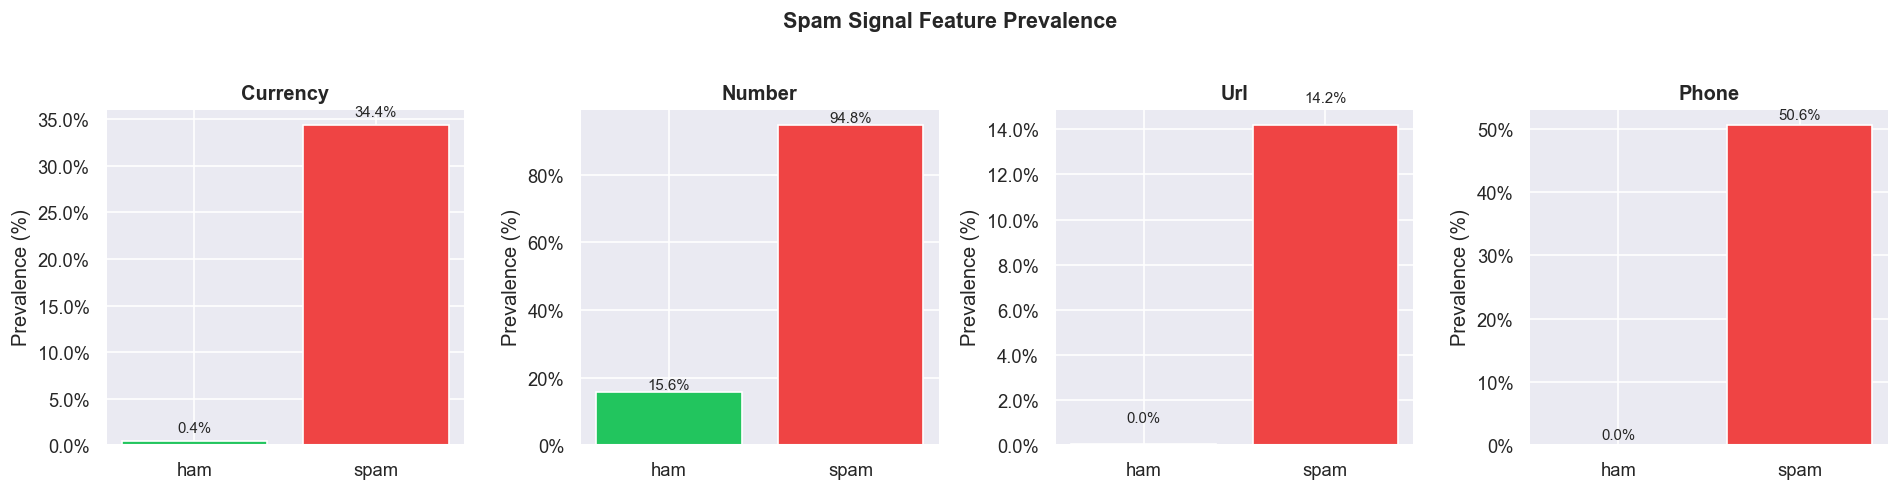

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(feature_cols):
    rates = df.groupby('label')[col].mean() * 100
    colors = ['#22c55e', '#ef4444']
    axes[i].bar(rates.index, rates.values, color=colors)
    axes[i].set_title(col.replace('contains_', '').title(), fontweight='bold')
    axes[i].set_ylabel('Prevalence (%)')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    for j, v in enumerate(rates.values):
        axes[i].text(j, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Spam Signal Feature Prevalence', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../readme-resources/eda_features.png', bbox_inches='tight')
plt.show()

## 6. Caps Ratio Analysis

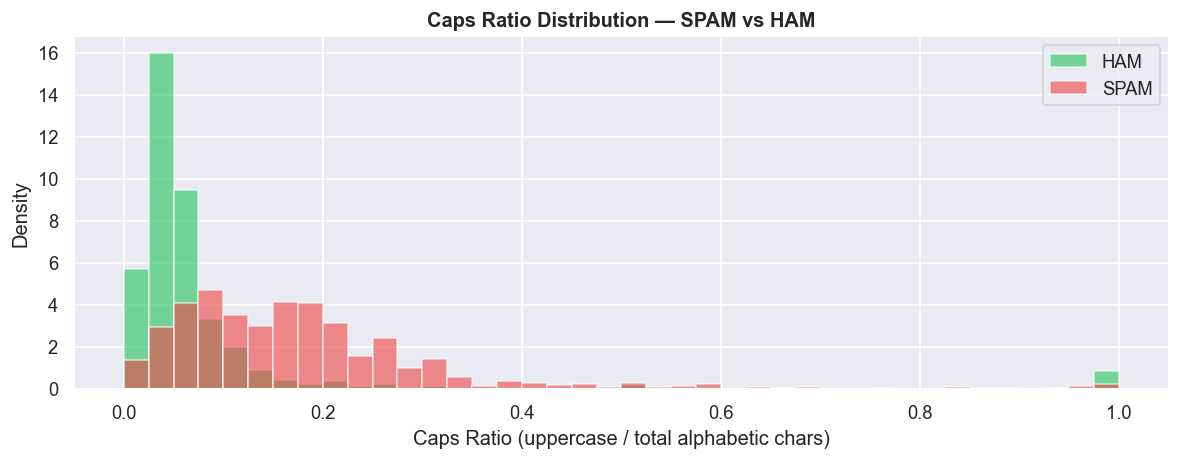

INSIGHT: Spam messages have a higher caps_ratio — used as a feature for Romanised Indic text too.


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for label, color in [('ham', '#22c55e'), ('spam', '#ef4444')]:
    ax.hist(df[df['label'] == label]['caps_ratio'], bins=40, alpha=0.6,
            label=label.upper(), color=color, density=True)
ax.set_xlabel('Caps Ratio (uppercase / total alphabetic chars)')
ax.set_ylabel('Density')
ax.set_title('Caps Ratio Distribution — SPAM vs HAM', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print('INSIGHT: Spam messages have a higher caps_ratio — used as a feature for Romanised Indic text too.')

## 7. EDA Summary

| Finding | Detail |
|---------|--------|
| Dataset size | 5,572 rows |
| Class imbalance | 86.6% HAM / 13.4% SPAM |
| Spam messages are longer | Spam avg 138 chars vs Ham avg 71 chars |
| URL prevalence | 36% of spam vs 0.5% of ham |
| Currency symbol | 31% of spam vs 1.2% of ham |
| Phone number | 19% of spam vs 3% of ham |
| Caps ratio | Higher in spam (promotional language) |

**Design implication**: Weighted cross-entropy loss (not oversampling) for MuRIL.
SMOTE applied to LightGBM fallback TF-IDF feature space only.